# S&P 500 Equity + Option Analytics: Feasibility Analysis

`config/setup.yaml` declares a strategy that ranks S&P 500 shares by signals read off their
listed options and holds the shares. This notebook asks whether the data supports that.

## Learning objectives

- Count the universe by what the strategy can rank, not by what the files contain
- Read clearance off an exceedance curve, and see why a per-share and a percentage cost model
  are different assumptions rather than two units for one
- Measure how long the volatility level stays put, and confirm the declared folds fit

## Book reference

Chapter 6, Sections 6.2-6.6. Reads the surface, the bars and `config/setup.yaml`.

In [1]:
"""S&P 500 Equity + Option Analytics - Feasibility Analysis."""

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

## Configuration

Every knob comes from `setup.yaml`, and Sections B through D compute on the development window
alone, so nothing the holdout contains shapes a choice made here. The signal ranked on is the
thirty-day at-the-money implied volatility, whose persistence B.4 measures.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
HORIZONS = sorted({int(h.rstrip("D")) for h in SETUP["labels"]["horizons"].values()})
BREADTH_FLOOR = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
COST_BPS = SETUP["costs"]["round_trip_cost_bps"]
PER_SHARE = SETUP["costs"]["per_share"]
HALF_SPREADS = SETUP["backtest"]["sweep"]["cost_grid_half_spread_usd"]
CARRIER = "iv_30_atm"
IV_LAG, IV_STALE = 1, 5  # declared feature lag; sessions 03_financial_features forward-fills

print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(f"Universe {SETUP['universe']['n_assets']} names, floor {BREADTH_FLOOR}, horizons {HORIZONS}")

Development 2017-01-01 to 2021-01-01 | sealed holdout to 2021-12-31
Universe 633 names, floor 20, horizons [5, 10]


## A. Orientation

The options market prices the distribution of a share's future returns and the equity market
prices its level. This case study reads the first and trades the second, so signal and cost
arrive from two venues that need not cover the same names on the same days. Does the universe
exist on the dates the strategy acts on? Is a typical move large next to the spread? Are there
enough decision dates for a walk-forward clear of the holdout?

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe

The surface carries implied volatility interpolated to fixed tenors, one row per name and
session, with `qc_converged_share` scoring how cleanly the points behind it solved; the bars
carry `close` as printed plus `adj_factor`. A name is present where the interpolation produced a
value and a bar exists, the condition `03_financial_features` reads it under.

In [4]:
surface = load_sp500_options_surface(start_date=START_DATE, end_date=END_DATE)
bars = load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)
sealed = pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date()
quotes = bars.filter(sealed).select("timestamp", "symbol", "sec_id", "close", "adj_factor")

panel = (
    surface.filter(sealed)
    .select("timestamp", "symbol", CARRIER)
    .drop_nulls(CARRIER)
    .join(quotes.drop("sec_id"), ["timestamp", "symbol"])
    .sort(["symbol", "timestamp"])
)
print(
    f"{panel['symbol'].n_unique()} names, {len(panel):,} name-sessions, "
    f"{panel['timestamp'].n_unique():,} sessions to {panel['timestamp'].max()}"
)

609 names, 332,096 name-sessions, 1,007 sessions to 2020-12-31


### B.2 Breadth at every decision date

`setup.yaml::universe.n_assets` counts the names appearing anywhere in the sample; what a
cross-sectional strategy spends is the names it can rank *on the session it acts on*, against
the sweep's largest position count as the floor it clears to fill a book. Ranking reads the
volatility a session late and `03_financial_features` carries it forward over a short gap, so a
name counts here under that lag and that tolerance.

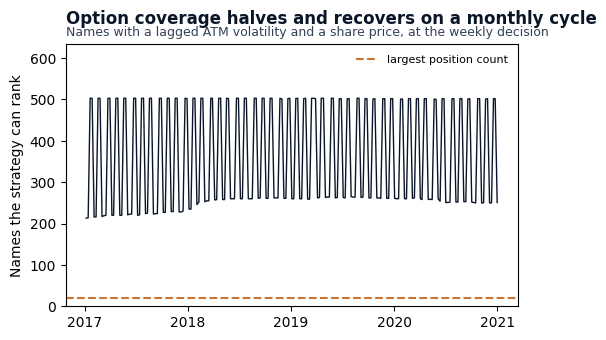

In [5]:
rankable = (
    quotes.select("timestamp", "symbol")
    .join(panel.select("timestamp", "symbol", CARRIER), ["timestamp", "symbol"], how="left")
    .sort(["symbol", "timestamp"])
    .with_columns(pl.col(CARRIER).shift(IV_LAG).forward_fill(limit=IV_STALE).over("symbol"))
    .drop_nulls(CARRIER)
)
decisions = rankable.group_by(pl.col("timestamp").dt.truncate("1w")).agg(
    pl.col("timestamp").max().alias("decision_date")
)
breadth = (
    rankable.join(decisions, left_on="timestamp", right_on="decision_date")
    .group_by("timestamp")
    .agg(pl.col("symbol").n_unique().alias("n_names"))
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n_names"], color=COLORS["blue"], linewidth=1.0)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="largest position count")
ax.set_ylim(0, SETUP["universe"]["n_assets"])
ax.set_ylabel("Names the strategy can rank")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(frameon=False, fontsize=8, loc="upper right")
add_message_title(
    ax,
    "Option coverage halves and recovers on a monthly cycle",
    subtitle="Names with a lagged ATM volatility and a share price, at the weekly decision",
)
plt.show()

Breadth never approaches the floor, so it is not what limits this strategy. What the swing
changes is *which* names can be ranked: on the narrow weeks the cross-section is about half the
panel, so a statistic averaged over decision dates spans two universes.

### B.3 What the trade costs, and what a move is worth

`setup.yaml::costs.model` declares a percentage regime: a flat round trip in basis points for
every name. The companion the sweep keeps is a per-share regime, where the charge is a number
of cents and the basis points follow from the price, so a cent buys a different fraction of a
cheap share than of an expensive one. Both come off the bars, not the joined panel, where a
horizon counted in rows stretches; and what follows is a move's size, not a payoff.

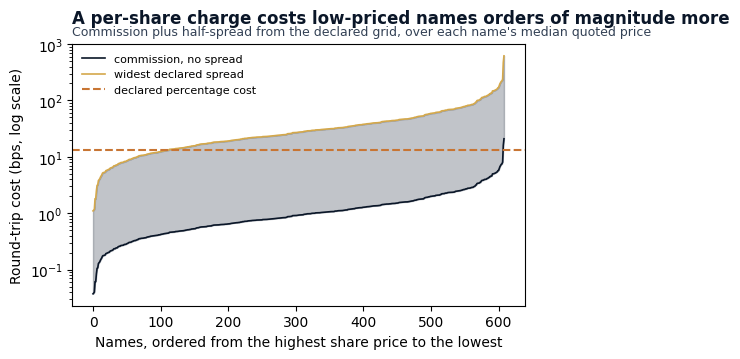

In [6]:
prices = (
    quotes.filter(pl.col("symbol").is_in(panel["symbol"].unique()))
    .with_columns((pl.col("close") * pl.col("adj_factor")).alias("adj"))
    .sort(["symbol", "sec_id", "timestamp"])
)
cost = (
    prices.group_by("symbol")
    .agg(pl.col("close").median().alias("price"))
    .with_columns(
        (2 * (min(HALF_SPREADS) + PER_SHARE) / pl.col("price") * 1e4).alias("cheapest"),
        (2 * (max(HALF_SPREADS) + PER_SHARE) / pl.col("price") * 1e4).alias("dearest"),
    )
    .sort("price", descending=True)
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
rank = np.arange(len(cost))
ax.fill_between(rank, cost["cheapest"], cost["dearest"], color=COLORS["blue"], alpha=0.25)
ax.plot(rank, cost["cheapest"], color=COLORS["blue"], lw=1.2, label="commission, no spread")
ax.plot(rank, cost["dearest"], color=COLORS["amber"], lw=1.2, label="widest declared spread")
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="declared percentage cost")
ax.set_yscale("log")
ax.set_xlabel("Names, ordered from the highest share price to the lowest")
ax.set_ylabel("Round-trip cost (bps, log scale)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
add_message_title(
    ax,
    "A per-share charge costs low-priced names orders of magnitude more",
    subtitle="Commission plus half-spread from the declared grid, over each name's median quoted price",
)
plt.show()

The two cross, so no single cent figure reproduces the flat line across a universe this wide in
price, which is why the percentage regime is the headline. Returns run close to close on the
adjusted series and within one security: a split cuts the printed close by its ratio, and a
ticker can change hands between two `sec_id` values.

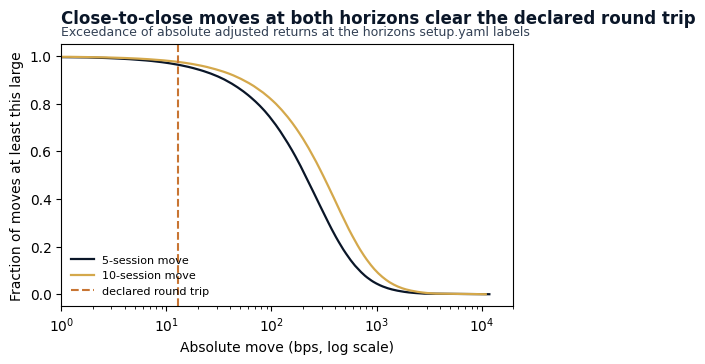

In [7]:
returns = prices.with_columns(
    (pl.col("adj").pct_change(h).abs().over(["symbol", "sec_id"]) * 1e4).alias(f"h{h}")
    for h in HORIZONS
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"]), strict=True):
    magnitude, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(magnitude, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="declared round trip")
ax.set_xscale("log")
ax.set_xlim(1, 20_000)
ax.set_xlabel("Absolute move (bps, log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Close-to-close moves at both horizons clear the declared round trip",
    subtitle="Exceedance of absolute adjusted returns at the horizons setup.yaml labels",
)
plt.show()

### B.4 How long the carrier stays put

Rebalancing weekly is worth the turnover only if what the data says at one decision date still
says something at the next, so the question is how fast the volatility level decays. The
autocorrelation runs inside each name, since stacking six hundred measures the joins between
them, and over the names quoting every session, since a lag over a gap is not one.

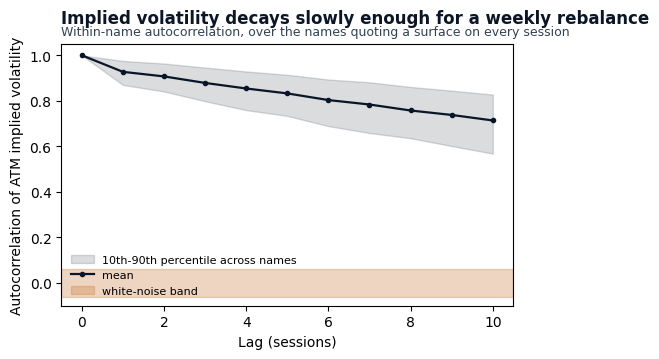

In [8]:
whole = panel.group_by("symbol").len().filter(pl.col("len") == panel["timestamp"].n_unique())
contiguous = panel.filter(pl.col("symbol").is_in(whole["symbol"]))
acf = panel_acf(contiguous, entity_col="symbol", value_col=CARRIER, max_lags=max(HORIZONS))

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
band, spread = acf["band"][0], "10th-90th percentile across names"
ax.fill_between(
    acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15, label=spread
)
ax.plot(acf["lag"], acf["acf"], color=COLORS["blue"], lw=1.6, marker="o", ms=3, label="mean")
ax.axhspan(-band, band, color=COLORS["copper"], alpha=0.3, label="white-noise band")
ax.set_ylim(-0.1, 1.05)
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("Autocorrelation of ATM implied volatility")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Implied volatility decays slowly enough for a weekly rebalance",
    subtitle="Within-name autocorrelation, over the names quoting a surface on every session",
)
plt.show()

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the declared round trip
and the clearance share counts moves above it. Neither says total cost clears.

In [9]:
primary = f"h{HORIZONS[0]}"
median_move, clears_cost = (
    returns.drop_nulls(primary)
    .select(pl.col(primary).median(), (pl.col(primary) > COST_BPS).mean().alias("share"))
    .row(0)
)
print(
    f"Per-share round trip {cost['cheapest'].min():.2f} to {cost['dearest'].max():.0f} bps "
    f"against a declared flat {COST_BPS} bps | median {HORIZONS[0]}-session move "
    f"{median_move:.0f} bps, ratio {median_move / COST_BPS:.0f}x, clearing {clears_cost:.3f}"
)

Per-share round trip 0.04 to 619 bps against a declared flat 13 bps | median 5-session move 209 bps, ratio 16x, clearing 0.964


The median absolute five-session move is 209 bps, sixteen times the declared 13 bps round
trip, and 0.964 of moves exceed it. Priced per share instead, the same round trip runs
from 0.04 bps on the most expensive name to 619 bps on the cheapest.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` snapshots at the Friday close and executes at the Monday open,
with a one-day lag so a surface published after the close cannot be read before it exists. B.4
supports the weekly interval: the carrier holds most of its level a week out, so a daily
rebalance pays the spread again for information that has not moved.

### C.2 Kill conditions

Three thresholds send the setup back to be revised, each tested where its evidence exists, not
here: the information coefficient of the volatility families falling below its floor across
folds, the move-to-cost ratio falling under one after realistic costs, and the volatility
features adding nothing over realized volatility.

### C.3 Mapping class

`setup.yaml::mapping.class` holds the top of the ranking long and equally weighted. Long-only
keeps borrow and locate frictions out of an example whose subject is the signal, and equal
weight avoids stacking a second optimization on the ranking. Chapter 17 sweeps the allocators.

## D. Walk-forward structure

### D.1 Effective sample size

What evaluation spends is decision dates, not rows, and B.4 is why this sample is tighter than
the count suggests: adjacent weeks of a slow carrier are not independent.

In [10]:
print(
    f"Sessions {panel['timestamp'].n_unique():,} | decision dates {len(decisions):,} | "
    f"names per decision {breadth['n_names'].mean():.0f}"
)

Sessions 1,007 | decision dates 209 | names per decision 367


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone. Between each
training and validation block sits a purge gap the width of the label buffer, so a label
computed inside training cannot resolve inside validation. The figure draws the boundaries the
splitter returned, so the two cannot come apart.

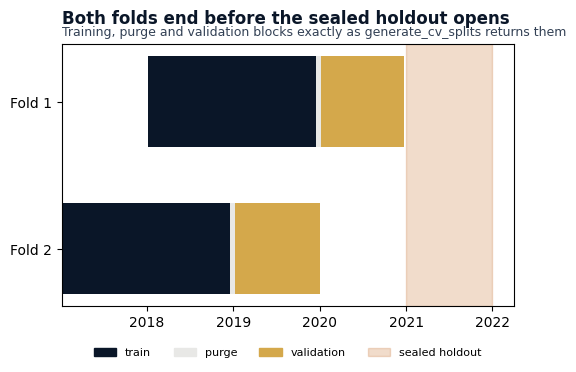

In [11]:
splits = generate_cv_splits(
    panel.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    outcome_horizon=SETUP["labels"]["horizons"][PRIMARY_LABEL],
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "Both folds end before the sealed holdout opens",
    subtitle="Training, purge and validation blocks exactly as generate_cv_splits returns them",
)
plt.show()

## E. Derived artifacts

None. `03_financial_features` derives the same universe from the same loader.

## F. Findings vs `setup.yaml`
| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.n_assets` | B.2 breadth at each decision date | names available on a decision date fall towards the largest position count the sweep asks for |
| `decision.cadence` | B.3 exceedance, B.4 persistence | the carrier decays inside one rebalancing interval, or moves stop clearing the round trip |
| `costs.model` | B.3 per-share band against the flat line | a per-name spread measurement arrives, which is what would make the per-share regime the headline |
| `evaluation.n_splits` | D.1 decision dates, D.2 boundaries | the folds no longer fit the development window ahead of the holdout |

In [12]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, names per decision date "
    f"{breadth['n_names'].min()} to {breadth['n_names'].max()}, under the floor on "
    f"{breadth.filter(pl.col('n_names') < BREADTH_FLOOR).height} of {len(breadth)} dates\n"
    f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL} | "
    f"carrier autocorrelation at the primary horizon {acf['acf'][HORIZONS[0]]:.2f}\n"
    f"costs.model {SETUP['costs']['model']} at {COST_BPS} bps | "
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 633, names per decision date 213 to 503, under the floor on 0 of 209 dates
decision.cadence weekly_friday_close | labels.primary fwd_ret_5d | carrier autocorrelation at the primary horizon 0.83
costs.model percentage at 13 bps | evaluation.n_splits 2, generated 2, last validation ends 2020-12-23, holdout untouched


Names available at a decision date run from 213 to 503 against a declared universe of 633
and a floor of 20, which no date approaches. The ATM volatility level retains 0.83 of
itself five sessions on. Two folds are generated, the last validation ending 2020-12-23.

## Key takeaways

1. **Count the universe by what the strategy can rank**, not by what the files contain.
2. **A percentage and a per-share cost model are different assumptions about friction.**
3. **Adjust prices, keep to one security, and take a panel autocorrelation inside each entity.**

### Known limitations

- The development window is four years, and a slow carrier shortens it further in effect.
- Cost is the declared spread and commission; impact enters at the cost stage.

**Next**: labels at the declared horizons, on this development window.